# Stage E — Basin Discharge Modeling (Daily, Exogenous-only)

**Goal.** Train first-cut ML models to predict **daily basin discharge** from
**ERA5 basin-aggregated features** + **static basin attributes**. Evaluate against strong baselines and pick a champion per basin.

---

## Inputs

- (Derived in Stage D) **Joined training table (exogenous):**  
  `data/modeling/datasets/train_basin_daily_exogenous.parquet`

---

## Outputs

- **Metrics tables**
  - Baselines, Ridge, Tree: `data/modeling/reports/stageE_*_metrics.csv`

---

## Pipeline (what each step does)

1. **Load & sanity-check the training table**
   - Ensure expected columns: `['basin_id','date_local','discharge_cms', … features …]`
   - Report dtype mix, duplicate keys, per-basin date coverage, and % missing.

2. **Feature screening (numeric only)**
   - Remove **constant** columns.
   - Confirmed no columns with all missing values.
   - Keep the cleaned numeric feature list `FEAT_NUMERIC`.

3. **Time-ordered splits (per basin)**
   - For each basin: `train → val → test` (no overlap, no leakage).
   - Concatenate across basins to form pooled `TRAIN / VAL / TEST`.

4. **Baselines**
   - **Climatology** (train-mean).
   - **Persistence** (ŷt = yt-1).
   - Compute metrics on VAL/TEST: `MAE, RMSE, R², NSE, KGE`.

5. **Metric helpers**
   - Reusable functions to score arrays/DataFrames and to format tables.

6. **Pooled linear model (Ridge)**
   - Fit on **log1p(discharge)** with **StandardScaler**.
   - Small α grid; select **best by VAL NSE**.
   - Evaluate on VAL/TEST and store predictions.

7. **Pooled tree model**
   - Try LightGBM → XGBoost → **RandomForest** (fallback), all on **log1p(discharge)**.
   - Light tuning, select **best by VAL NSE**, evaluate VAL/TEST.

8. **Comparison & champion selection**
   - Merge all metrics; build **VAL/TEST NSE** pivots.
   - Compute **skill vs persistence** (NSE gain, RMSE reduction).
   - Pick **champion per basin** = highest **VAL NSE** (tie-break: lower RMSE).
   - Report **TEST** metrics for the champions.

9. **Presentation figures**
   - **Bars**: NSE by basin & model (VAL/TEST).
   - **Hydrographs**: Observed vs predicted (TEST) for each basin.
   - **Residual seasonality**: residuals by month (TEST).

---

## Key choices / assumptions

- Daily horizon; **exogenous-only** (no lagged discharge).
- Target transformed with **log1p**, predictions **expm1** then clipped ≥ 0.
- Splits are **chronological within basin**; metrics reported by basin and overall.

In [86]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [2]:
# === Resolve Project Root ===
def get_project_root(max_up=6):
    try:
        root = subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip()
        if root:
            return Path(root)
    except Exception:
        pass
    p = Path.cwd()
    for _ in range(max_up):
        if (p/"data").exists() and (p/"code").exists():
            return p
        if (p/".git").exists():
            return p
        p = p.parent
    return Path.cwd()

PROJECT_ROOT = get_project_root()
print("Project root:", PROJECT_ROOT)

Project root: /Users/liuq13/bhutan_climate_modeling


In [3]:
EXOG_PATH = PROJECT_ROOT / "data/modeling/datasets/train_basin_daily_exogenous.parquet"
print("Exogenous path:", EXOG_PATH)

Exogenous path: /Users/liuq13/bhutan_climate_modeling/data/modeling/datasets/train_basin_daily_exogenous.parquet


## Step 1: Load & sanity-check

In [4]:
# --- Helpers (load + summarize) ---
def load_parquet_normalized(path: Path) -> pd.DataFrame:
    """Load parquet and normalize date_local to naive midnight; coerce basin_id to int where possible."""
    df = pd.read_parquet(path)
    if "date_local" in df.columns:
        df["date_local"] = pd.to_datetime(df["date_local"]).dt.tz_localize(None).dt.normalize()
    if "basin_id" in df.columns:
        # coerce safely; if there are NaN, leave them as Int64 (nullable)
        try:
            df["basin_id"] = pd.to_numeric(df["basin_id"], errors="coerce").astype("Int64")
        except Exception:
            pass
    return df

def summarize_dataset(name: str, df: pd.DataFrame, key=("basin_id","date_local")):
    print(f"\n=== [{name}] shape: {df.shape} ===")
    
    # columns by dtype
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    dt_cols  = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    print(f"\nNumeric cols ({len(num_cols)}):", num_cols[:15], "..." if len(num_cols)>15 else "")
    print(f"Datetime cols ({len(dt_cols)}):", dt_cols)
    print(f"Object cols ({len(obj_cols)}):", obj_cols)

    # key missingness
    for k in ["discharge_cms","qc_any"]:
        if k in df.columns:
            frac = df[k].isna().mean()*100
            print(f"Missing {k}: {frac:.2f}%")

    # duplicate (basin_id, date_local)
    if all(k in df.columns for k in key):
        dup = df.duplicated(list(key)).sum()
        print(f"Duplicate ({key[0]},{key[1]}) rows:", dup)

    # per-basin summary
    if "basin_id" in df.columns and "date_local" in df.columns:
        g = (df.groupby("basin_id", dropna=False)
               .agg(first_day=("date_local","min"),
                    last_day =("date_local","max"),
                    n_days   =("date_local","nunique"),
                    n_rows   =("date_local","size"),
                    miss_y   =("discharge_cms", lambda s: int(s.isna().sum()) if "discharge_cms" in df.columns else np.nan))
               .reset_index()
               .sort_values("basin_id"))
        print("\nPer-basin date coverage:")
        display(g.head(20))
        print("Total basins:", g["basin_id"].nunique())

    # quick peek
    print("\nHead:")
    display(df.head(3))


In [5]:
# --- Run sanity checks (no filtering yet) ---
exog_df = load_parquet_normalized(EXOG_PATH)  # raises if missing
summarize_dataset("EXOGENOUS", exog_df)


=== [EXOGENOUS] shape: (29185, 180) ===

Numeric cols (178): ['basin_id', 'potential_evaporation_sum_1d', 'potential_evaporation_sum_3d', 'potential_evaporation_sum_7d', 'potential_evaporation_sum_14d', 'potential_evaporation_sum_30d', 'precipitation_sum_1d', 'precipitation_sum_3d', 'precipitation_sum_7d', 'precipitation_sum_14d', 'precipitation_sum_30d', 'runoff_sum_1d', 'runoff_sum_3d', 'runoff_sum_7d', 'runoff_sum_14d'] ...
Datetime cols (1): ['date_local']
Object cols (1): ['basin_name']
Missing discharge_cms: 0.14%
Missing qc_any: 0.00%
Duplicate (basin_id,date_local) rows: 0

Per-basin date coverage:


,basin_id,first_day,last_day,n_days,n_rows,miss_y
0,3,2000-01-01,2023-12-31,8584,8584,0
1,6,1991-04-22,2024-12-31,11964,11964,0
2,8,2000-01-01,2023-12-31,8637,8637,42


Total basins: 3

Head:


,basin_id,date_local,potential_evaporation_sum_1d,potential_evaporation_sum_3d,potential_evaporation_sum_7d,potential_evaporation_sum_14d,potential_evaporation_sum_30d,precipitation_sum_1d,precipitation_sum_3d,precipitation_sum_7d,...,Plinthosols_pct,Podzols_pct,Regosols_pct,Solonchaks_pct,Solonetz_pct,Stagnosols_pct,Umbrisols_pct,Vertisols_pct,discharge_cms,qc_any
0,3,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000046,0.0,0.0,0.0,0.0,0.0,0.0,14.783,False
1,3,2000-01-02,-0.000222,NaN,NaN,NaN,NaN,0.000018,NaN,NaN,...,0.0,0.000046,0.0,0.0,0.0,0.0,0.0,0.0,14.620,False
2,3,2000-01-03,-0.000248,NaN,NaN,NaN,NaN,0.000029,NaN,NaN,...,0.0,0.000046,0.0,0.0,0.0,0.0,0.0,0.0,14.565,False


## Step 2: Apply data policy & define features
This step coerces `qc_any` to a proper Boolean column (creating it if missing), ensures `basin_id` is integer-like, and filters the dataset to keep only rows that pass QC (`qc_any=False`) and have non-missing `discharge_cms`.


In [6]:
# --- Step 2.1: Coerce qc_any -> boolean and filter rows ---
def to_bool_series(s: pd.Series) -> pd.Series:
    """Robust bool coercion (returns pandas Boolean dtype)."""
    if s.dtype == bool:
        return s.astype("boolean")
    truthy = {"true","t","yes","y","1",1,True}
    falsy  = {"false","f","no","n","0",0,False}
    def _cast(v):
        if pd.isna(v):
            return pd.NA
        v2 = str(v).strip().lower()
        if v2 in truthy: return True
        if v2 in falsy:  return False
        return pd.NA
    return s.map(_cast).astype("boolean")

# Work on a copy of the exogenous dataset first
work = exog_df.copy()

# Coerce qc_any -> boolean (create if absent, default False = keep)
if "qc_any" in work.columns:
    work["qc_any"] = to_bool_series(work["qc_any"])
else:
    work["qc_any"] = pd.Series(False, index=work.index, dtype="boolean")

# Ensure basin_id is integer-like
work["basin_id"] = pd.to_numeric(work["basin_id"], errors="coerce").astype("Int64")

# Policy: keep rows with qc_any == False AND non-null discharge
mask_keep = (work["qc_any"] == False) & (work["discharge_cms"].notna())
kept_rows = mask_keep.sum()
print(f"Rows kept after policy: {kept_rows} / {len(work)} ({kept_rows/len(work):.1%})")
exog_clean = work.loc[mask_keep].copy()

# Sanity peek
exog_clean[["basin_id","date_local","discharge_cms","qc_any"]].head()


Rows kept after policy: 29143 / 29185 (99.9%)


,basin_id,date_local,discharge_cms,qc_any
0,3,2000-01-01,14.783,False
1,3,2000-01-02,14.620,False
2,3,2000-01-03,14.565,False
3,3,2000-01-04,14.031,False
4,3,2000-01-05,14.032,False


In [7]:
# --- Build numeric-only feature list and report missingness/constancy ---

RESERVED = {"basin_id","date_local","discharge_cms","qc_any","basin_name"} 

# numeric candidate features (exclude reserved)
num_candidates = [c for c in exog_clean.columns
                  if c not in RESERVED and pd.api.types.is_numeric_dtype(exog_clean[c])]

print(f"Numeric candidate features: {len(num_candidates)}")

Numeric candidate features: 175


This step next generates a feature-quality report, computing the missing-value fraction and flagging constant or all-NaN features, then displays the top 20 and prints how many should be dropped.


In [8]:
# Report missing fraction & constant flags (on the filtered data)
miss_frac = exog_clean[num_candidates].isna().mean()
is_const  = exog_clean[num_candidates].nunique(dropna=True) <= 1

feature_report = (pd.DataFrame({
    "missing_frac": miss_frac,
    "is_constant":  is_const
}).sort_values(["is_constant","missing_frac"], ascending=[False, False]))

print("Any all-NaN features:", int((miss_frac==1.0).sum()))
print("Any constant features:", int(is_const.sum()))

Any all-NaN features: 0
Any constant features: 44


In [9]:
# --- Drop constant features and update dataset ---

# Identify constant columns (only 1 unique value)
const_cols = exog_clean[num_candidates].nunique(dropna=True)
const_cols = const_cols[const_cols <= 1].index.tolist()

print(f"Dropping {len(const_cols)} constant features...")
for c in const_cols:
    print("  ", c)

# Update dataset to remove them
exog_clean = exog_clean.drop(columns=const_cols)

print("New shape after dropping constants:", exog_clean.shape)


Dropping 44 constant features...
   Acrisols_km2
   Albeluvisols_km2
   Andosols_km2
   Arenosols_km2
   Calcisols_km2
   Chernozems_km2
   Durisols_km2
   Ferralsols_km2
   Gleysols_km2
   Gypsisols_km2
   Histosols_km2
   Kastanozems_km2
   Lixisols_km2
   Nitisols_km2
   Phaeozems_km2
   Planosols_km2
   Plinthosols_km2
   Regosols_km2
   Solonchaks_km2
   Solonetz_km2
   Stagnosols_km2
   Umbrisols_km2
   Acrisols_pct
   Albeluvisols_pct
   Andosols_pct
   Arenosols_pct
   Calcisols_pct
   Chernozems_pct
   Durisols_pct
   Ferralsols_pct
   Gleysols_pct
   Gypsisols_pct
   Histosols_pct
   Kastanozems_pct
   Lixisols_pct
   Nitisols_pct
   Phaeozems_pct
   Planosols_pct
   Plinthosols_pct
   Regosols_pct
   Solonchaks_pct
   Solonetz_pct
   Stagnosols_pct
   Umbrisols_pct
New shape after dropping constants: (29143, 136)


## Step 3: per-basin time splits (70/15/15)
This function adds a `"split"` column to the dataset, assigning each row to train/val/test **chronologically per basin** using a (70%, 15%, 15%) rule. It ensures each split has at least one day and uses date cutoffs to avoid data leakage across time.


In [11]:
# --- Add chronological train/val/test splits per basin ---
def add_time_splits(
    df: pd.DataFrame,
    id_col: str = "basin_id",
    date_col: str = "date_local",
    rule=(0.70, 0.15, 0.15),
) -> pd.DataFrame:
    """
    Label each row with 'train'/'val'/'test' per basin using chronological splits.
    Splits are based on the sorted UNIQUE dates within each basin.
    """
    out = df.copy()
    out["split"] = pd.NA

    for b, g in out.sort_values([id_col, date_col]).groupby(id_col, sort=False):
        dates = np.array(sorted(g[date_col].dropna().unique()))
        n = len(dates)
        if n < 10:
            out.loc[g.index, "split"] = "train"
            continue

        # compute cut sizes (ensure at least 1 test day)
        n_train = int(np.floor(rule[0] * n))
        n_val   = int(np.floor(rule[1] * n))
        if n_train < 1: n_train = 1
        if n_val   < 1: n_val = 1
        if n_train + n_val >= n:  # leave at least 1 for test
            n_val = max(1, n - n_train - 1)
        n_test  = n - n_train - n_val
        if n_test < 1:
            n_test = 1
            if n_val > 1:
                n_val -= 1

        cut_train = dates[n_train - 1]
        cut_val   = dates[n_train + n_val - 1]

        idx = g.index
        d   = out.loc[idx, date_col]
        out.loc[idx, "split"] = np.where(
            d <= cut_train, "train",
            np.where(d <= cut_val, "val", "test")
        )

    return out

In [12]:
# Apply to cleaned exogenous table from Step 2
exog_split = add_time_splits(exog_clean, id_col="basin_id", date_col="date_local", rule=(0.70,0.15,0.15))
print("Null splits:", int(exog_split["split"].isna().sum()))

Null splits: 0


In [14]:
exog_split.head()

,basin_id,date_local,potential_evaporation_sum_1d,potential_evaporation_sum_3d,potential_evaporation_sum_7d,potential_evaporation_sum_14d,potential_evaporation_sum_30d,precipitation_sum_1d,precipitation_sum_3d,precipitation_sum_7d,...,Cambisols_pct,Cryosols_pct,Fluvisols_pct,Leptosols_pct,Luvisols_pct,Podzols_pct,Vertisols_pct,discharge_cms,qc_any,split
0,3,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.157322,0.040418,0.0,0.073291,0.728905,0.000046,0.0,14.783,False,train
1,3,2000-01-02,-0.000222,NaN,NaN,NaN,NaN,0.000018,NaN,NaN,...,0.157322,0.040418,0.0,0.073291,0.728905,0.000046,0.0,14.620,False,train
2,3,2000-01-03,-0.000248,NaN,NaN,NaN,NaN,0.000029,NaN,NaN,...,0.157322,0.040418,0.0,0.073291,0.728905,0.000046,0.0,14.565,False,train
3,3,2000-01-04,-0.000225,-0.000695,NaN,NaN,NaN,0.000090,0.000136,NaN,...,0.157322,0.040418,0.0,0.073291,0.728905,0.000046,0.0,14.031,False,train
4,3,2000-01-05,-0.000241,-0.000714,NaN,NaN,NaN,0.000015,0.000134,NaN,...,0.157322,0.040418,0.0,0.073291,0.728905,0.000046,0.0,14.032,False,train


In [15]:
# counts (rows) by basin × split
count_tbl = (exog_split
             .groupby(["basin_id","split"], dropna=False)
             .size()
             .unstack("split", fill_value=0)
             .reset_index()
             .sort_values("basin_id"))
display(count_tbl)

split,basin_id,test,train,val
0,3,1289,6008,1287
1,6,1796,8374,1794
2,8,1290,6016,1289


In [16]:
# date ranges by basin × split
span_tbl = (exog_split
            .groupby(["basin_id","split"])
            .agg(first=("date_local","min"), last=("date_local","max"))
            .unstack("split"))
# tidy column names
span_tbl.columns = [f"{sp}_{which}" for which, sp in span_tbl.columns]
span_tbl = span_tbl.reset_index().sort_values("basin_id")
display(span_tbl)

,basin_id,test_first,train_first,val_first,test_last,train_last,val_last
0,3,2020-05-30,2000-01-01,2016-10-22,2023-12-31,2016-10-21,2020-05-29
1,6,2019-12-01,1991-04-22,2014-11-16,2024-12-31,2014-11-15,2019-11-30
2,8,2020-04-29,2000-01-01,2016-09-20,2023-12-31,2016-09-19,2020-04-28


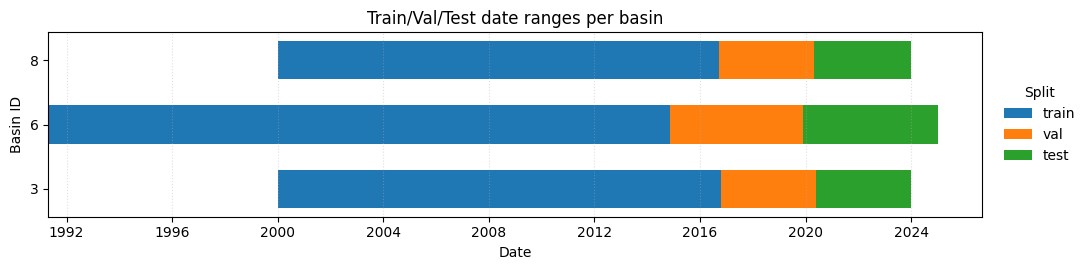

In [17]:
# --- Visualization of dataset splits ---

def plot_split_timeline(span_tbl: pd.DataFrame, basin_order=None):
    """
    Draw a Gantt-style timeline of train/val/test date ranges per basin.

    Expects columns:
        basin_id, train_first, train_last, val_first, val_last, test_first, test_last
    """
    df = span_tbl.copy()

    # Ensure datetime
    date_cols = [c for c in df.columns if c.endswith("_first") or c.endswith("_last")]
    for c in date_cols:
        df[c] = pd.to_datetime(df[c])

    # Long format: one row per (basin, split) with start/end
    parts = []
    for sp in ["train", "val", "test"]:
        parts.append(
            df[["basin_id", f"{sp}_first", f"{sp}_last"]]
              .rename(columns={f"{sp}_first":"start", f"{sp}_last":"end"})
              .assign(split=sp)
        )
    long = pd.concat(parts, ignore_index=True)

    # Order basins on the y-axis
    if basin_order is None:
        basin_order = sorted(df["basin_id"].unique())
    y_map = {b:i for i,b in enumerate(basin_order)}

    # Plot
    fig, ax = plt.subplots(figsize=(11, 0.6*len(basin_order) + 1))
    # Colors are optional; comment out next line to use defaults
    colors = {"train":"tab:blue", "val":"tab:orange", "test":"tab:green"}

    # Convert to Matplotlib date numbers
    long["start_num"] = mdates.date2num(long["start"])
    long["width"] = (long["end"] - long["start"]).dt.days.clip(lower=1)  # at least 1 day

    for sp, g in long.groupby("split", sort=False):
        ax.barh(
            [y_map[b] for b in g["basin_id"]],
            g["width"],
            left=g["start_num"],
            height=0.6,
            label=sp,
            color=colors.get(sp, None)
        )

    ax.set_yticks(range(len(basin_order)))
    ax.set_yticklabels(basin_order)
    ax.set_ylabel("Basin ID")
    ax.set_xlabel("Date")
    ax.set_title("Train/Val/Test date ranges per basin")
    ax.legend(
    title="Split", ncols=1, loc="center left",
    bbox_to_anchor=(1.01, 0.5), frameon=False)
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
    ax.grid(True, axis="x", linestyle=":", alpha=0.4)
    fig.tight_layout()
    return fig, ax

# --- Call the plots ---
_ = plot_split_timeline(span_tbl)      # uses your span_tbl from Step 3.2

## Step 4: Build Design Matrices per Basin (Train-Median Impute; No One-Hot)

For each basin, the dataset is split chronologically into train/val/test sets.  
Features that are entirely NaN in the **train split** are dropped, and remaining NaNs are filled using **train medians** (per basin).  
This produces clean, per-basin matrices `(Xtr, ytr, Xva, yva, Xte, yte)` with consistent feature sets, ready for modeling.


In [31]:
# --- Build design matrices per basin (train-median impute; no one-hot) ---

def build_design_matrices_per_basin(df: pd.DataFrame,
                                    feature_cols: list,
                                    id_col: str = "basin_id",
                                    y_col: str = "discharge_cms",
                                    date_col: str = "date_local"):
    """
    Returns:
      dict[basin_id] -> (Xtr, ytr, Xva, yva, Xte, yte, feature_names)
    - Imputes feature NaNs with TRAIN medians (per basin).
    - Drops features that are all-NaN in the TRAIN split for that basin.
    """
    out = {}
    df = df.sort_values([id_col, date_col]).copy()

    for b, g in df.groupby(id_col, sort=False):
        tr = g[g["split"] == "train"]
        va = g[g["split"] == "val"]
        te = g[g["split"] == "test"]

        # Drop features that are entirely NaN in TRAIN for this basin
        allna_in_train = tr[feature_cols].isna().all()
        keep_cols = [c for c in feature_cols if not allna_in_train[c]]
        if len(keep_cols) == 0:
            raise ValueError(f"No usable features for basin {b} (all NaN in train).")

        # Train medians for imputation (per basin)
        med = tr[keep_cols].median()

        Xtr = tr[keep_cols].fillna(med).to_numpy(dtype=float)
        Xva = va[keep_cols].fillna(med).to_numpy(dtype=float)
        Xte = te[keep_cols].fillna(med).to_numpy(dtype=float)
        ytr = tr[y_col].to_numpy()
        yva = va[y_col].to_numpy()
        yte = te[y_col].to_numpy()

        # Safety checks
        if any(np.isnan(X).any() for X in (Xtr, Xva, Xte)):
            raise ValueError(f"NaNs remain in features for basin {b}")
        if any(np.isnan(y).any() for y in (ytr, yva, yte)):
            raise ValueError(f"NaNs found in target for basin {b}")
        assert len(ytr)==len(Xtr) and len(yva)==len(Xva) and len(yte)==len(Xte), \
            f"X/y length mismatch in basin {b}"

        out[int(b) if pd.notna(b) else b] = (Xtr, ytr, Xva, yva, Xte, yte, keep_cols)
        print(f"[Basin {b}] kept {len(keep_cols)} features | shapes Xtr{Xtr.shape}, Xva{Xva.shape}, Xte{Xte.shape}")

    return out


In [32]:
# Automatically select only numeric columns
numeric_cols = exog_split.select_dtypes(include=["number"]).columns
feature_cols = [c for c in numeric_cols if c not in ["basin_id", "discharge_cms"]]

In [33]:
# NaN fraction per basin for your feature set
nan_report = exog_split.groupby("basin_id")[feature_cols].apply(lambda g: g.isna().mean())
print(nan_report.T.head(15))  # transpose for readability

basin_id                              3         6         8
potential_evaporation_sum_1d   0.000116  0.000084  0.000116
potential_evaporation_sum_3d   0.000349  0.000251  0.000349
potential_evaporation_sum_7d   0.000815  0.000585  0.000814
potential_evaporation_sum_14d  0.001631  0.001170  0.001629
potential_evaporation_sum_30d  0.003495  0.002508  0.003490
precipitation_sum_1d           0.000116  0.000084  0.000116
precipitation_sum_3d           0.000349  0.000251  0.000349
precipitation_sum_7d           0.000815  0.000585  0.000814
precipitation_sum_14d          0.001631  0.001170  0.001629
precipitation_sum_30d          0.003495  0.002508  0.003490
runoff_sum_1d                  0.000116  0.000084  0.000116
runoff_sum_3d                  0.000349  0.000251  0.000349
runoff_sum_7d                  0.000815  0.000585  0.000814
runoff_sum_14d                 0.001631  0.001170  0.001629
runoff_sum_30d                 0.003495  0.002508  0.003490


In [34]:
per_basin_data = build_design_matrices_per_basin(exog_split, feature_cols)

[Basin 3] kept 131 features | shapes Xtr(6008, 131), Xva(1287, 131), Xte(1289, 131)
[Basin 6] kept 131 features | shapes Xtr(8374, 131), Xva(1794, 131), Xte(1796, 131)
[Basin 8] kept 131 features | shapes Xtr(6016, 131), Xva(1289, 131), Xte(1290, 131)


## Step 5: baselines (climatology & persistence)

### Step 5.1: Metrics helpers (ignore NaN pairs)

In [35]:
# Filter to pairs where both y and yhat are non-NaN (returns aligned arrays)
def _valid_pairs(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    m = ~(np.isnan(y) | np.isnan(yhat))
    return y[m], yhat[m]

# Mean Absolute Error (ignoring NaN pairs)
def mae(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    return np.mean(np.abs(y - yhat))

# Root Mean Squared Error (ignoring NaN pairs)
def rmse(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

# Coefficient of determination R^2 (NaN if y is constant)
def r2(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    if y.size == 0:
        return np.nan
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Nash–Sutcliffe Efficiency (equivalent to R^2 with mean benchmark)
def nse(y, yhat):
    return r2(y, yhat)

# Kling–Gupta Efficiency (2009): combines correlation, variability, and bias ratios
def kge(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    if y.size == 0:
        return np.nan
    r = np.corrcoef(y, yhat)[0, 1] if np.std(y) > 0 and np.std(yhat) > 0 else np.nan
    alpha = np.std(yhat) / np.std(y) if np.std(y) > 0 else np.nan
    beta = np.mean(yhat) / np.mean(y) if np.mean(y) != 0 else np.nan
    if any(map(np.isnan, [r, alpha, beta])):
        return np.nan
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

# Package metrics (plus metadata) into a single dict, counting valid pairs
def metric_row(y, yhat, extra: dict):
    return dict(
        **extra,
        n=len(_valid_pairs(y, yhat)[0]),
        mae=mae(y, yhat),
        rmse=rmse(y, yhat),
        r2=r2(y, yhat),
        nse=nse(y, yhat),
        kge=kge(y, yhat),
    )

### 5.2 Baseline Models (Climatology & Persistence)

- **fit_climatology:** Computes per-basin day-of-year median discharge, plus basin-wide and global medians for fallback.
- **predict_climatology:** Generates predictions by joining on basin+DOY medians, falling back to basin median or global median if needed.
- **predict_persistence:** Implements a persistence baseline (`ŷ(t) = y(t-1)`) per basin, using the full dataset so validation rows can use the last training value.


In [41]:
# --- Step 5.2: Baseline predictors ---

def fit_climatology(train_df: pd.DataFrame) -> dict:
    """
    Per-basin day-of-year median discharge.
    Fallbacks:
      - basin-wide median (train)
      - global median (train)
    Returns a dict with three Series/DataFrames to use in prediction.
    """
    tr = train_df.copy()
    tr["doy"] = tr["date_local"].dt.dayofyear.clip(upper=365)  # map 366 -> 365
    # per-basin-day median
    med_basin_doy = (tr.groupby(["basin_id", "doy"])["discharge_cms"]
                       .median().rename("q_med"))
    # per-basin overall median
    med_basin = tr.groupby("basin_id")["discharge_cms"].median().rename("q_med_basin")
    # global median
    med_global = float(tr["discharge_cms"].median())
    return {"by_basin_doy": med_basin_doy, "by_basin": med_basin, "global": med_global}

def predict_climatology(df_part: pd.DataFrame, model: dict) -> np.ndarray:
    part = df_part.copy()
    part["doy"] = part["date_local"].dt.dayofyear.clip(upper=365)

    # join basin-doy median
    key = ["basin_id", "doy"]
    pred = part.merge(model["by_basin_doy"].reset_index(), on=key, how="left")["q_med"]

    # fallback to basin median
    miss = pred.isna()
    if miss.any():
        pred.loc[miss] = part.loc[miss].merge(
            model["by_basin"].reset_index(), on="basin_id", how="left"
        )["q_med_basin"].values

    # fallback to global median
    pred.fillna(model["global"], inplace=True)
    return pred.to_numpy(dtype=float)

def predict_persistence(df_full: pd.DataFrame, df_part_idx: pd.Index) -> np.ndarray:
    """
    Persistence: y_hat(t) = y(t-1), computed within each basin on the full split table
    so the first VAL day can use the last TRAIN day (realistic at inference).
    """
    srt = df_full.sort_values(["basin_id", "date_local"]).copy()
    srt["y_pers"] = srt.groupby("basin_id")["discharge_cms"].shift(1)
    # pull back to the requested rows (VAL/TEST)
    return srt.loc[df_part_idx, "y_pers"].to_numpy(dtype=float)


### 5.3 Evaluate baselines on VAL & TEST (per-basin + overall)

- **metrics_for_split:** Calculates MAE, RMSE, R², NSE, and KGE per basin and overall for a given split, returning a list of metric dictionaries.
- **eval_baselines:** Fits climatology on train data, predicts climatology and persistence for val/test, computes metrics with `metrics_for_split`, and returns a tidy metrics DataFrame plus prediction tables for plotting.


In [42]:
# --- Step 5.3 (patched): Evaluate baselines per-basin + overall ---

def metrics_for_split(df_part: pd.DataFrame, yhat: np.ndarray,
                      track_name: str, baseline_name: str, split_label: str):
    """
    Build metric rows for each basin and an overall row, using df_part masks
    (avoids grouping mistakes on the Series).
    """
    rows = []
    assert len(df_part) == len(yhat), "Prediction length mismatch."

    # Per-basin rows
    for b in sorted(pd.to_numeric(df_part["basin_id"], errors="coerce").dropna().astype(int).unique()):
        msk = (df_part["basin_id"] == b)
        y_true_b = df_part.loc[msk, "discharge_cms"].values
        y_hat_b  = yhat[msk]
        rows.append(
            metric_row(
                y_true_b, y_hat_b,
                dict(track=track_name, model="baseline", baseline=baseline_name,
                     split=split_label, basin_id=int(b))
            )
        )

    # Overall row
    rows.append(
        metric_row(
            df_part["discharge_cms"].values, yhat,
            dict(track=track_name, model="baseline", baseline=baseline_name,
                 split=split_label, basin_id="ALL")
        )
    )
    return rows

def eval_baselines(df_split: pd.DataFrame, track_name="exogenous"):
    rows = []

    # Partitions
    train = df_split[df_split["split"] == "train"].copy()
    val   = df_split[df_split["split"] == "val"].copy()
    test  = df_split[df_split["split"] == "test"].copy()

    # Fit climatology on TRAIN
    clim = fit_climatology(train)

    # Climatology predictions
    yhat_val_clim  = predict_climatology(val,  clim)
    yhat_test_clim = predict_climatology(test, clim)

    # Persistence predictions (use full DF to allow train->val boundary lag)
    yhat_val_pers  = predict_persistence(df_split, val.index)
    yhat_test_pers = predict_persistence(df_split, test.index)

    # Collect metric rows
    rows += metrics_for_split(val,  yhat_val_clim,  track_name, "climatology", "val")
    rows += metrics_for_split(test, yhat_test_clim, track_name, "climatology", "test")
    rows += metrics_for_split(val,  yhat_val_pers,  track_name, "persistence", "val")
    rows += metrics_for_split(test, yhat_test_pers, track_name, "persistence", "test")

    metrics_df = pd.DataFrame(rows)[["track","model","baseline","split","basin_id","n","mae","rmse","r2","nse","kge"]]

    # Also return predictions if you want to plot later
    preds = {
        "val":  pd.DataFrame({"basin_id": val["basin_id"].values,
                              "date_local": val["date_local"].values,
                              "y_true": val["discharge_cms"].values,
                              "yhat_clim": yhat_val_clim,
                              "yhat_pers": yhat_val_pers}),
        "test": pd.DataFrame({"basin_id": test["basin_id"].values,
                              "date_local": test["date_local"].values,
                              "y_true": test["discharge_cms"].values,
                              "yhat_clim": yhat_test_clim,
                              "yhat_pers": yhat_test_pers}),
    }
    return metrics_df, preds

In [43]:
# Re-run baselines with the patched evaluator
baseline_metrics_exog, baseline_preds_exog = eval_baselines(exog_split, track_name="exogenous")
display(baseline_metrics_exog.sort_values(["split","basin_id","baseline"]))

,track,model,baseline,split,basin_id,n,mae,rmse,r2,nse,kge
4,exogenous,baseline,climatology,test,3,1289,10.031909,17.070635,0.850746,0.850746,0.916641
12,exogenous,baseline,persistence,test,3,1289,5.380677,10.823919,0.939994,0.939994,0.969980
5,exogenous,baseline,climatology,test,6,1796,5.112180,9.156939,0.769334,0.769334,0.850849
13,exogenous,baseline,persistence,test,6,1796,1.974102,4.673783,0.939907,0.939907,0.969952
6,exogenous,baseline,climatology,test,8,1290,70.045003,124.066135,0.805534,0.805534,0.838996
14,exogenous,baseline,persistence,test,8,1290,42.069159,82.063095,0.914919,0.914919,0.957451
7,exogenous,baseline,climatology,test,ALL,4375,25.707579,68.255688,0.889863,0.889863,0.881166
15,exogenous,baseline,persistence,test,ALL,4375,14.800091,45.046164,0.952030,0.952030,0.976013
0,exogenous,baseline,climatology,val,3,1287,8.509710,16.825163,0.866820,0.866820,0.859353
8,exogenous,baseline,persistence,val,3,1287,4.617256,10.148646,0.951545,0.951545,0.975773


In [ ]:
def plot_baseline_metric(metrics_df: pd.DataFrame, metric="r2", split="test"):
    """
    Bar chart of a single metric (e.g., 'r2','kge','rmse','mae') for a given split,
    comparing climatology vs persistence per basin (including ALL).
    """
    m = metrics_df[(metrics_df["split"] == split) & (metrics_df["model"] == "baseline")]
    # order basins numerically, put "ALL" at the end
    basins = [b for b in sorted(m.loc[m["basin_id"]!="ALL","basin_id"].astype(int))] + ["ALL"]
    piv = (m[m["baseline"].isin(["climatology","persistence"])]
             .pivot(index="basin_id", columns="baseline", values=metric)
             .reindex(basins))

    x = np.arange(len(piv.index))
    w = 0.38
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, piv["climatology"].values, width=w, label="climatology")
    ax.bar(x + w/2, piv["persistence"].values,  width=w, label="persistence")
    ax.set_xticks(x)
    ax.set_xticklabels(piv.index.astype(str), rotation=0)
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} by basin — {split}")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_baseline_metric(baseline_metrics_exog, metric="r2",  split="val")
plot_baseline_metric(baseline_metrics_exog, metric="r2",  split="test")

## Step 6: pooled Ridge model on log1p(discharge)

### 6.1 Train pooled Ridge (log1p target) and choose alpha on VAL

In [50]:


# --- ridge with log1p target; picks best alpha on VAL ---
def train_ridge_log1p(Xtr, ytr, Xva, yva, alphas=(0.1, 1, 3, 10, 30, 100, 300, 1000)):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr_s = scaler.fit_transform(Xtr)
    Xva_s = scaler.transform(Xva)

    ytr_log = np.log1p(np.clip(ytr, 0, None))
    scores, best = [], None
    for a in alphas:
        mdl = Ridge(alpha=float(a))
        mdl.fit(Xtr_s, ytr_log)
        yva_hat = np.expm1(mdl.predict(Xva_s))
        yva_hat = np.clip(yva_hat, 0, None)
        score = nse(yva, yva_hat)   # or r2(yva, yva_hat)
        scores.append((a, score))
        if (best is None) or (score > best[1]):
            best = (a, score, mdl)

    return {
        "alpha": best[0],
        "val_score": best[1],
        "model": best[2],
        "scaler": scaler,
        "scores": pd.DataFrame(scores, columns=["alpha","val_score"]).sort_values("alpha"),
    }

# --- train/evaluate per basin using per_basin_data ---
def run_ridge_per_basin(per_basin_data, track_name="exogenous"):
    rows, results = [], {}
    for b, (Xtr, ytr, Xva, yva, Xte, yte, names) in per_basin_data.items():
        out = train_ridge_log1p(Xtr, ytr, Xva, yva)
        mdl, scaler = out["model"], out["scaler"]

        # predictions (invert log1p and clip at 0)
        yva_hat = np.clip(np.expm1(mdl.predict(scaler.transform(Xva))), 0, None)
        yte_hat = np.clip(np.expm1(mdl.predict(scaler.transform(Xte))), 0, None)

        # metrics
        rows.append(metric_row(yva, yva_hat, dict(track=track_name, model="ridge_log1p", baseline="NA", split="val",  basin_id=b)))
        rows.append(metric_row(yte, yte_hat, dict(track=track_name, model="ridge_log1p", baseline="NA", split="test", basin_id=b)))

        results[b] = {**out, "yva_hat": yva_hat, "yte_hat": yte_hat, "feature_names": names}

        print(f"[Basin {b}] best alpha={out['alpha']} | VAL {out['val_score']:.4f}")

    metrics_df = pd.DataFrame(rows)[["track","model","split","basin_id","n","mae","rmse","r2","nse","kge"]]
    return metrics_df, results

# run it
ridge_metrics_pb, ridge_results_pb = run_ridge_per_basin(per_basin_data, track_name="exogenous")
display(ridge_metrics_pb.sort_values(["split","basin_id"]))


[Basin 3] best alpha=3 | VAL 0.9033
[Basin 6] best alpha=0.1 | VAL 0.7946
[Basin 8] best alpha=1 | VAL 0.9071


,track,model,split,basin_id,n,mae,rmse,r2,nse,kge
1,exogenous,ridge_log1p,test,3,1289,7.996611,13.049004,0.912787,0.912787,0.904132
3,exogenous,ridge_log1p,test,6,1796,5.146760,8.680708,0.792703,0.792703,0.754766
5,exogenous,ridge_log1p,test,8,1290,54.847020,91.180360,0.894963,0.894963,0.935768
0,exogenous,ridge_log1p,val,3,1287,7.177323,14.339767,0.903261,0.903261,0.883437
2,exogenous,ridge_log1p,val,6,1794,5.152985,8.529162,0.794616,0.794616,0.700822
4,exogenous,ridge_log1p,val,8,1289,39.616669,81.073198,0.907145,0.907145,0.877039


## Step 7: pooled tree-ensemble model

### 7.1 Pick a backend (LGBM → XGB → RF)

In [62]:
# --- Step 7.1: Choose tree backend (lgbm -> xgb -> rf) ---

TREE_BACKEND = None
try:
    import lightgbm as lgb
    TREE_BACKEND = "lgbm"
    print("Using LightGBM.")
except Exception:
    try:
        import xgboost as xgb
        TREE_BACKEND = "xgb"
        print("LightGBM not available; using XGBoost.")
    except Exception:
        from sklearn.ensemble import RandomForestRegressor
        TREE_BACKEND = "rf"
        print("LightGBM/XGBoost not available; using RandomForest as fallback.")


LightGBM not available; using XGBoost.


### 7.2 Train pooled tree on log1p(y) and choose best via VAL NSE

In [64]:
def train_tree_log1p(
    Xtr, ytr, Xva, yva,
    backend=TREE_BACKEND,
    random_state=42
):
    ytr_log = np.log1p(np.clip(ytr, 0, None))
    yva_true = yva.astype(float)

    candidates = []  # (name, model, val_nse)

    if backend == "lgbm":
        # small grid; early stopping on VAL
        grids = [
            dict(num_leaves=31, learning_rate=0.1, n_estimators=800),
            dict(num_leaves=31, learning_rate=0.05, n_estimators=1200),
            dict(num_leaves=15, learning_rate=0.1, n_estimators=800),
        ]
        for i, p in enumerate(grids):
            mdl = lgb.LGBMRegressor(
                num_leaves=p["num_leaves"],
                learning_rate=p["learning_rate"],
                n_estimators=p["n_estimators"],
                subsample=0.9, colsample_bytree=0.9,
                reg_alpha=0.0, reg_lambda=0.0,
                random_state=random_state, n_jobs=-1
            )
            mdl.fit(
                Xtr, ytr_log,
                eval_set=[(Xva, ytr_log[:len(Xva)])],  # we just need callbacks; metric on log target
                eval_metric="l2",
                callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
            )
            yva_hat = np.expm1(mdl.predict(Xva, num_iteration=mdl.best_iteration_))
            yva_hat = np.clip(yva_hat, 0, None)
            candidates.append((f"lgbm_{i}", mdl, nse(yva_true, yva_hat)))

    elif backend == "xgb":
        grids = [
            dict(max_depth=6, learning_rate=0.1, n_estimators=600),
            dict(max_depth=5, learning_rate=0.05, n_estimators=1000),
        ]
        for i, p in enumerate(grids):
            mdl = xgb.XGBRegressor(
                max_depth=p["max_depth"], learning_rate=p["learning_rate"],
                n_estimators=p["n_estimators"], subsample=0.9, colsample_bytree=0.9,
                objective="reg:squarederror", reg_alpha=0.0, reg_lambda=0.0,
                random_state=random_state, n_jobs=-1
            )
            mdl.fit(
                Xtr, ytr_log,
                eval_set=[(Xva, ytr_log[:len(Xva)])],
                verbose=False
            )
            yva_hat = np.expm1(mdl.predict(Xva))
            yva_hat = np.clip(yva_hat, 0, None)
            candidates.append((f"xgb_{i}", mdl, nse(yva_true, yva_hat)))

    else:  # rf fallback
        from sklearn.ensemble import RandomForestRegressor
        grids = [
            dict(n_estimators=600, max_depth=None),
            dict(n_estimators=600, max_depth=14),
        ]
        for i, p in enumerate(grids):
            mdl = RandomForestRegressor(
                n_estimators=p["n_estimators"], max_depth=p["max_depth"],
                random_state=random_state, n_jobs=-1
            )
            mdl.fit(Xtr, ytr_log)
            yva_hat = np.expm1(mdl.predict(Xva))
            yva_hat = np.clip(yva_hat, 0, None)
            candidates.append((f"rf_{i}", mdl, nse(yva_true, yva_hat)))

    # pick best
    best = max(candidates, key=lambda t: (t[2] if not np.isnan(t[2]) else -np.inf))
    return {"name": best[0], "model": best[1], "val_nse": best[2], "backend": backend}

In [69]:
def predict_with_tree(tree_pack, X):
    """Use trained tree model in tree_pack to predict (log1p target inverted)."""
    yhat = tree_pack["model"].predict(X)
    if yhat.ndim > 1:  # Some libs return 2D
        yhat = yhat.ravel()
    return np.clip(np.expm1(yhat), 0, None)

all_tree_metrics = []

for b, (Xtr, ytr, Xva, yva, Xte, yte, names) in per_basin_data.items():
    # Train tree model per basin
    tree_pack = train_tree_log1p(Xtr, ytr, Xva, yva, backend=TREE_BACKEND)

    # Predict on VAL and TEST for this basin
    yva_hat = predict_with_tree(tree_pack, Xva)
    yte_hat = predict_with_tree(tree_pack, Xte)

    # Collect metrics per split
    all_tree_metrics.append(
        metric_row(yva, yva_hat,
            dict(track="exogenous", model=f"{tree_pack['backend']}_log1p",
                 split="val", basin_id=b))
    )
    all_tree_metrics.append(
        metric_row(yte, yte_hat,
            dict(track="exogenous", model=f"{tree_pack['backend']}_log1p",
                 split="test", basin_id=b))
    )

    print(f"[Basin {b}] {tree_pack['backend']} chosen={tree_pack['name']} | VAL NSE={tree_pack['val_nse']:.3f}")

tree_metrics_df = pd.DataFrame(all_tree_metrics)[["track","model","split","basin_id","n","mae","rmse","r2","nse","kge"]]
display(tree_metrics_df.sort_values(["split","basin_id"]))


[Basin 3] xgb chosen=xgb_1 | VAL NSE=0.896
[Basin 6] xgb chosen=xgb_1 | VAL NSE=0.805
[Basin 8] xgb chosen=xgb_0 | VAL NSE=0.889


,track,model,split,basin_id,n,mae,rmse,r2,nse,kge
1,exogenous,xgb_log1p,test,3,1289,9.476028,15.307080,0.879992,0.879992,0.860767
3,exogenous,xgb_log1p,test,6,1796,4.982633,7.997268,0.824059,0.824059,0.810005
5,exogenous,xgb_log1p,test,8,1290,61.254368,102.346893,0.867661,0.867661,0.899236
0,exogenous,xgb_log1p,val,3,1287,7.013503,14.836961,0.896436,0.896436,0.882584
2,exogenous,xgb_log1p,val,6,1794,4.826230,8.301527,0.805433,0.805433,0.762965
4,exogenous,xgb_log1p,val,8,1289,42.967193,88.671932,0.888923,0.888923,0.883123


## Step 8: Model comparison

In [82]:
# Create a consistent model label so baselines vs models are easy to compare
bm = baseline_metrics_exog.assign(model_key="baseline:" + baseline_metrics_exog["baseline"])
rm = ridge_metrics_pb.assign(model_key="ridge_log1p")
tm = tree_metrics_df.assign(model_key=f"{TREE_BACKEND}_log1p")

metrics_all = (pd.concat([bm, rm, tm], ignore_index=True)
                 .sort_values(["split", "basin_id", "model_key"])
                 .reset_index(drop=True))
metrics_all

,track,model,baseline,split,basin_id,n,mae,rmse,r2,nse,kge,model_key
0,exogenous,baseline,climatology,test,3,1289,10.031909,17.070635,0.850746,0.850746,0.916641,baseline:climatology
1,exogenous,baseline,persistence,test,3,1289,5.380677,10.823919,0.939994,0.939994,0.969980,baseline:persistence
2,exogenous,ridge_log1p,NaN,test,3,1289,7.996611,13.049004,0.912787,0.912787,0.904132,ridge_log1p
3,exogenous,xgb_log1p,NaN,test,3,1289,9.476028,15.307080,0.879992,0.879992,0.860767,xgb_log1p
4,exogenous,baseline,climatology,test,6,1796,5.112180,9.156939,0.769334,0.769334,0.850849,baseline:climatology
5,exogenous,baseline,persistence,test,6,1796,1.974102,4.673783,0.939907,0.939907,0.969952,baseline:persistence
6,exogenous,ridge_log1p,NaN,test,6,1796,5.146760,8.680708,0.792703,0.792703,0.754766,ridge_log1p
7,exogenous,xgb_log1p,NaN,test,6,1796,4.982633,7.997268,0.824059,0.824059,0.810005,xgb_log1p
8,exogenous,baseline,climatology,test,8,1290,70.045003,124.066135,0.805534,0.805534,0.838996,baseline:climatology
9,exogenous,baseline,persistence,test,8,1290,42.069159,82.063095,0.914919,0.914919,0.957451,baseline:persistence


In [93]:
# Save with directory creation
import os

reports_folder = "data/modeling/reports"

# Create directory if it doesn't exist
os.makedirs(os.path.join(PROJECT_ROOT, reports_folder), exist_ok=True)

parquet_path = os.path.join(PROJECT_ROOT, reports_folder, "stageE_metrics_all.parquet")
csv_path = os.path.join(PROJECT_ROOT, reports_folder, "stageE_metrics_all.csv")

metrics_all['basin_id'] = metrics_all['basin_id'].astype(str)

try:
    metrics_all.to_parquet(parquet_path, index=False)
    metrics_all.to_csv(csv_path, index=False)
    print(f"Saved metrics to {os.path.basename(parquet_path)} and {os.path.basename(csv_path)}")
except Exception as e:
    print(f"Error saving files: {e}")
    raise

Error saving files: [Errno 21] Failed to open local file '/Users/liuq13/bhutan_climate_modeling/data/modeling/reports/stageE_metrics_all.parquet'. Detail: [errno 21] Is a directory


IsADirectoryError: [Errno 21] Failed to open local file '/Users/liuq13/bhutan_climate_modeling/data/modeling/reports/stageE_metrics_all.parquet'. Detail: [errno 21] Is a directory

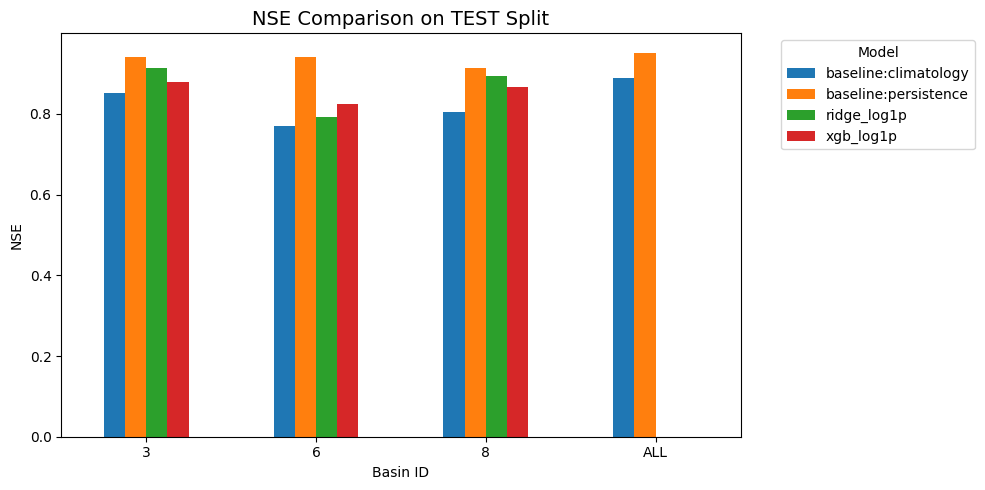

In [81]:
# Load if starting fresh
# metrics_all = pd.read_parquet("stage8_metrics_all.parquet")

# Filter to TEST split only
test_metrics = metrics_all[metrics_all["split"] == "test"]

# Pivot to wide format for plotting
plot_df = test_metrics.pivot_table(index="basin_id", columns="model_key", values="nse", aggfunc="first")

# Plot as bar chart
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("NSE Comparison on TEST Split", fontsize=14)
plt.ylabel("NSE")
plt.xlabel("Basin ID")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
